# Flight Delay Prediction - Exploratory Data Analysis (EDA)

**Objective:** Comprehensive analysis of flight delay patterns to inform ML model development

**Dataset:** 148,052 flights from 2017-2018

**Key Analyses:**
1. Target variable distribution and class imbalance
2. Temporal patterns (time, day, season)
3. Geographic patterns (airports, states)
4. Carrier performance analysis
5. Distance and route analysis
6. Feature correlations
7. Anomaly detection

## 1. Setup & Configuration

In [1]:
# Standard imports
import os, joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from dotenv import load_dotenv

load_dotenv() 

import warnings

# Configure warnings (show important ones only)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)

# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
sns.set_context("notebook", font_scale=1.1)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

# Set random seed for reproducibility
np.random.seed(42)

In [2]:
# Configuration
DATA_PATH = os.getenv("DATA_PATH")
VIZ_PATH = os.getenv("VIZ_PATH")

## 2. Data Loading & Initial Inspection

In [3]:
# Load data 
try:
    df = pd.read_csv(DATA_PATH)
    print("Data loaded successfully")
    print(f"   Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
except FileNotFoundError:
    print(f"ERROR: File not found at {DATA_PATH}")
    print("Please check the file path and try again.")
    raise
except Exception as e:
    print(f"ERROR loading data: {str(e)}")
    raise

Data loaded successfully
   Shape: 148,052 rows × 19 columns


In [4]:
df.head(5)

,YEAR,QUARTER,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,FL_DATE,UNIQUE_CARRIER,ORIGIN,ORIGIN_CITY_NAME,ORIGIN_STATE_ABR,DEST,DEST_CITY_NAME,DEST_STATE_ABR,DEP_TIME,ARR_TIME,ARR_DELAY,AIR_TIME,DISTANCE,DISTANCE_GROUP
0,2017,3,7,11,2,7/11/2017,DL,LIT,"Little Rock, AR",AR,ATL,"Atlanta, GA",GA,538,757,-11.0000,64,453,2
1,2018,1,3,14,3,3/14/2018,DL,BOS,"Boston, MA",MA,ATL,"Atlanta, GA",GA,1829,2108,-23.0000,127,946,4
2,2017,4,11,12,7,11/12/2017,WN,ATL,"Atlanta, GA",GA,DAL,"Dallas, TX",TX,1345,1451,-9.0000,106,721,3
3,2017,3,8,22,2,8/22/2017,EV,ATL,"Atlanta, GA",GA,HPN,"White Plains, NY",NY,1158,1408,-21.0000,113,780,4
4,2018,1,3,2,5,3/2/2018,DL,MSY,"New Orleans, LA",LA,ATL,"Atlanta, GA",GA,522,737,-19.0000,59,425,2


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148052 entries, 0 to 148051
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   YEAR              148052 non-null  int64  
 1   QUARTER           148052 non-null  int64  
 2   MONTH             148052 non-null  int64  
 3   DAY_OF_MONTH      148052 non-null  int64  
 4   DAY_OF_WEEK       148052 non-null  int64  
 5   FL_DATE           148052 non-null  object 
 6   UNIQUE_CARRIER    148052 non-null  object 
 7   ORIGIN            148052 non-null  object 
 8   ORIGIN_CITY_NAME  148052 non-null  object 
 9   ORIGIN_STATE_ABR  148052 non-null  object 
 10  DEST              148052 non-null  object 
 11  DEST_CITY_NAME    148052 non-null  object 
 12  DEST_STATE_ABR    148052 non-null  object 
 13  DEP_TIME          148052 non-null  int64  
 14  ARR_TIME          148052 non-null  int64  
 15  ARR_DELAY         147985 non-null  float64
 16  AIR_TIME          14

In [6]:
# Statistical summary
df.describe()

,YEAR,QUARTER,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,DEP_TIME,ARR_TIME,ARR_DELAY,AIR_TIME,DISTANCE,DISTANCE_GROUP
count,148052.0000,148052.0000,148052.0000,148052.0000,148052.0000,148052.0000,148052.0000,147985.0000,148052.0000,148052.0000,148052.0000
mean,2017.3431,2.4621,6.3726,15.7754,3.8988,1344.0323,1477.7309,1.8764,93.4351,657.9450,3.1070
std,0.4748,1.1034,3.3802,8.7731,1.9878,496.2748,512.5448,44.0041,55.3810,469.2782,1.8183
min,2017.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,-173.0000,15.0000,83.0000,1.0000
25%,2017.0000,1.0000,3.0000,8.0000,2.0000,939.0000,1103.0000,-15.0000,60.0000,373.0000,2.0000
50%,2017.0000,2.0000,6.0000,16.0000,4.0000,1335.0000,1504.0000,-7.0000,83.0000,566.0000,3.0000
75%,2018.0000,3.0000,9.0000,23.0000,6.0000,1738.2500,1911.0000,4.0000,106.0000,746.0000,3.0000
max,2018.0000,4.0000,12.0000,31.0000,7.0000,2400.0000,2400.0000,1455.0000,631.0000,4502.0000,11.0000


In [7]:
# Check for missing values
df.isnull().sum()


YEAR                 0
QUARTER              0
MONTH                0
DAY_OF_MONTH         0
DAY_OF_WEEK          0
FL_DATE              0
UNIQUE_CARRIER       0
ORIGIN               0
ORIGIN_CITY_NAME     0
ORIGIN_STATE_ABR     0
DEST                 0
DEST_CITY_NAME       0
DEST_STATE_ABR       0
DEP_TIME             0
ARR_TIME             0
ARR_DELAY           67
AIR_TIME             0
DISTANCE             0
DISTANCE_GROUP       0
dtype: int64

In [8]:
print(f"\nDuplicate Records: {df.duplicated().sum()}")


Duplicate Records: 0


## 3. Target Variable Analysis

Understanding the class distribution is critical for ML model selection and evaluation.

In [9]:
# Create binary target: delayed if ARR_DELAY > 15 minutes (industry standard)
df['IS_DELAYED'] = (df['ARR_DELAY'] > 15).astype(int)

print("Delay Statistics:")
print(df['ARR_DELAY'].describe())

print(f"\nEarly Arrivals (negative delay): {(df['ARR_DELAY'] < 0).sum():,} ({(df['ARR_DELAY'] < 0).sum()/len(df)*100:.1f}%)")
print(f"On-time (0-15 min): {((df['ARR_DELAY'] >= 0) & (df['ARR_DELAY'] <= 15)).sum():,} ({((df['ARR_DELAY'] >= 0) & (df['ARR_DELAY'] <= 15)).sum()/len(df)*100:.1f}%)")
print(f"Delayed (>15 min): {(df['ARR_DELAY'] > 15).sum():,} ({(df['ARR_DELAY'] > 15).sum()/len(df)*100:.1f}%)")

print(f"\nTarget Variable: IS_DELAYED_15")
print(f"  Delayed Flights: {df['IS_DELAYED'].sum():,} ({df['IS_DELAYED'].mean()*100:.1f}%)")
print(f"  On-time Flights: {(1-df['IS_DELAYED']).sum():,} ({(1-df['IS_DELAYED'].mean())*100:.1f}%)")

Delay Statistics:
count   147985.0000
mean         1.8764
std         44.0041
min       -173.0000
25%        -15.0000
50%         -7.0000
75%          4.0000
max       1455.0000
Name: ARR_DELAY, dtype: float64

Early Arrivals (negative delay): 100,375 (67.8%)
On-time (0-15 min): 26,298 (17.8%)
Delayed (>15 min): 21,312 (14.4%)

Target Variable: IS_DELAYED_15
  Delayed Flights: 21,312 (14.4%)
  On-time Flights: 126,740 (85.6%)


## 4. Exploratory Data Analysis

### 4.1 Delay Distribution Visualization

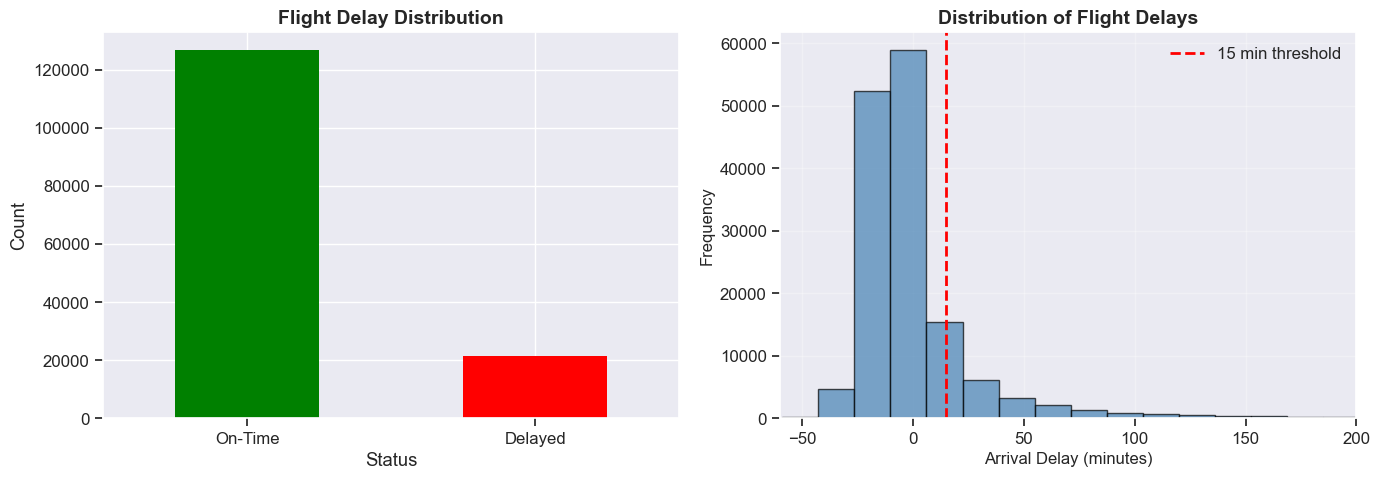

In [10]:
# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Delay distribution
df['IS_DELAYED'].value_counts().plot(kind='bar', ax=axes[0], color=['green', 'red'])
axes[0].set_title('Flight Delay Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['On-Time', 'Delayed'], rotation=0)

# Delay minutes histogram
axes[1].hist(df['ARR_DELAY'], bins=100, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].axvline(x=15, color='red', linestyle='--', linewidth=2, label='15 min threshold')
axes[1].set_xlabel('Arrival Delay (minutes)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Distribution of Flight Delays', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].set_xlim(-60, 200)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    f"{VIZ_PATH}/viz01_delay_distributions.png",
    bbox_inches="tight",
    dpi=150
)
plt.show()
plt.close()

**Key Findings:**
- Severe class imbalance (85/15 split) requires special ML techniques
- Most delays cluster near 15-minute threshold
- Right-skewed distribution with long tail of extreme delays

### 4.2 Temporal Analysis

Time-based patterns are critical for delay prediction.

In [11]:
# Extract hour from DEP_TIME
df['HOUR'] = (df['DEP_TIME'] // 100).astype(int)


In [12]:
# Calculate delay rates by different time dimensions
delay_by_dow = df.groupby('DAY_OF_WEEK')['IS_DELAYED'].mean() * 100
delay_by_month = df.groupby('MONTH')['IS_DELAYED'].mean() * 100
delay_by_hour = df.groupby('HOUR')['IS_DELAYED'].mean() * 100
flights_by_hour = df.groupby('HOUR').size()

print(" Temporal Delay Rates Calculated:")
print(f" - By Day of Week: {len(delay_by_dow)} categories")
print(f" - By Month: {len(delay_by_month)} categories")
print(f" - By Hour: {len(delay_by_hour)} categories")

 Temporal Delay Rates Calculated:
 - By Day of Week: 7 categories
 - By Month: 12 categories
 - By Hour: 25 categories


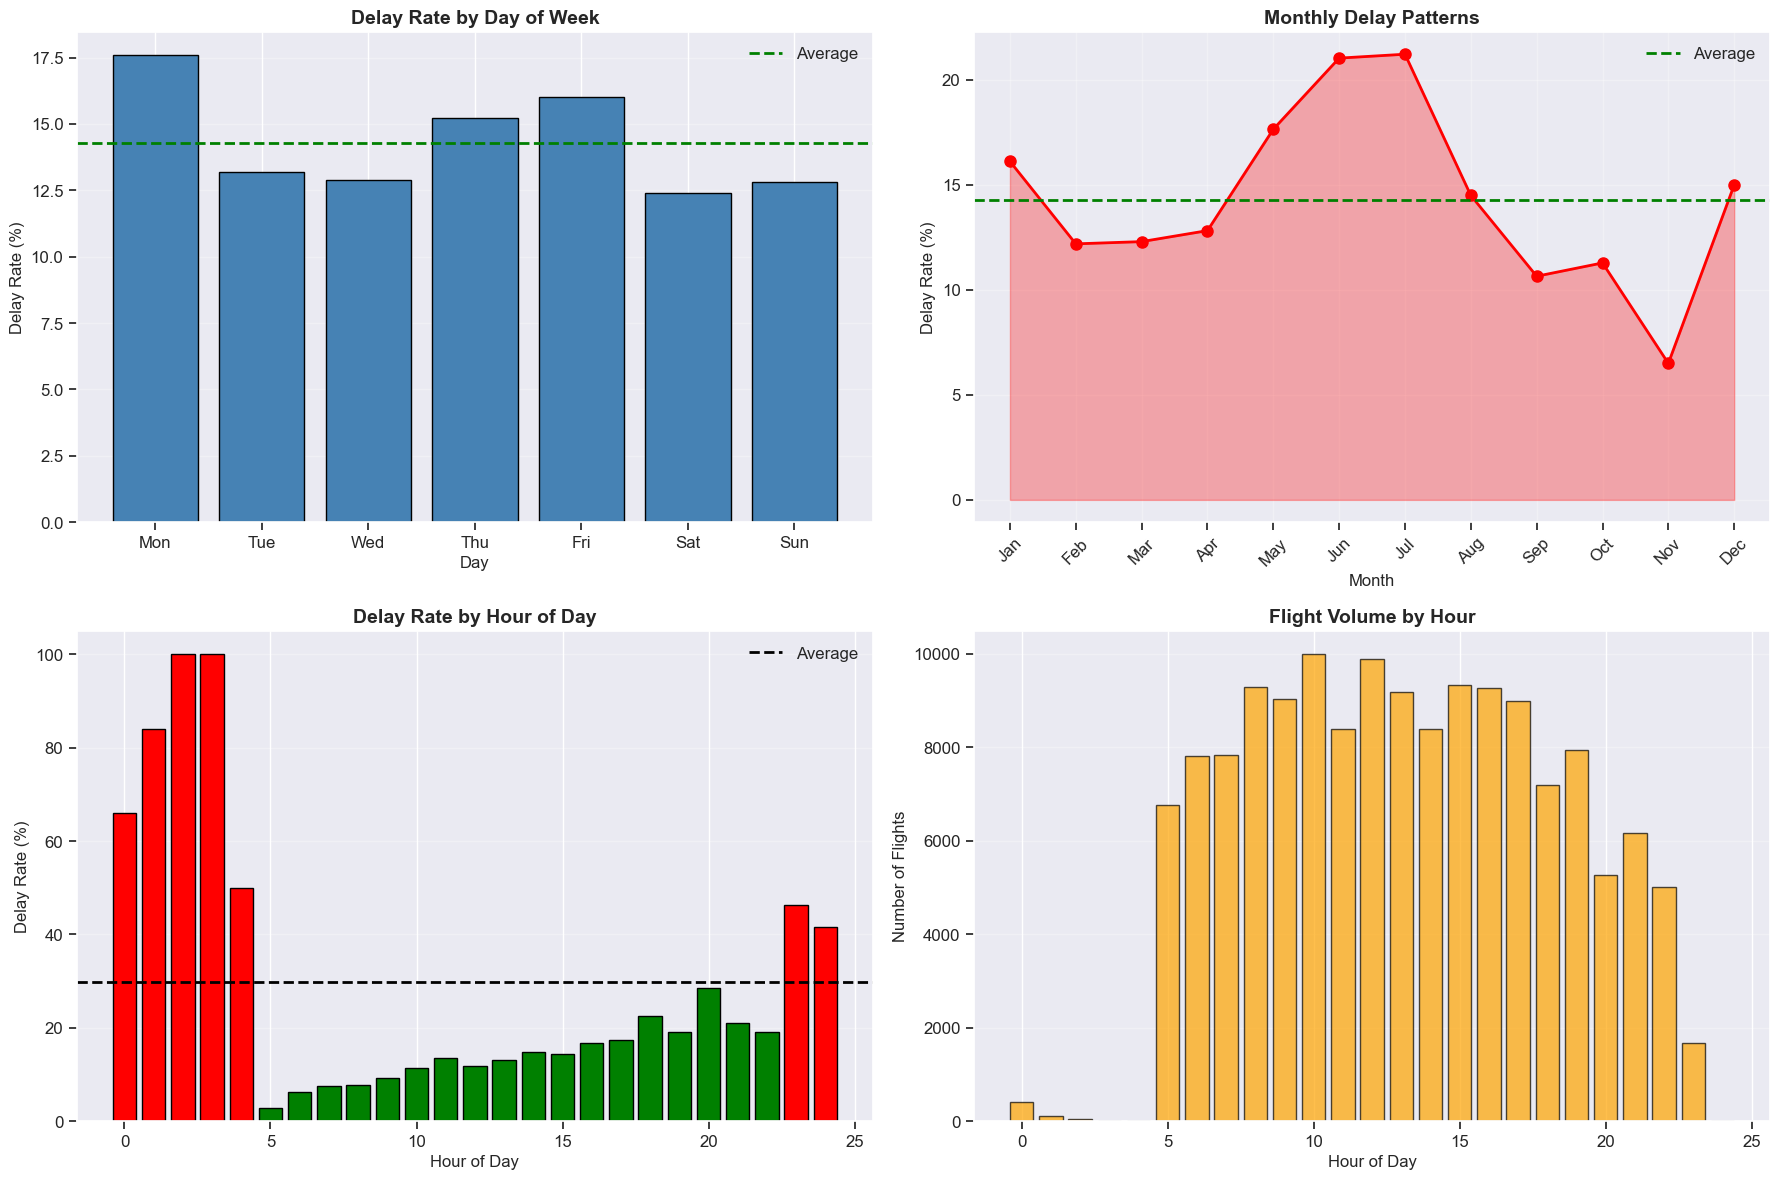

In [13]:
# Temporal patterns visualization
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Day of week
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[0, 0].bar(range(len(delay_by_dow)), delay_by_dow.values, color='steelblue', edgecolor='black')
axes[0, 0].axhline(y=delay_by_dow.mean(), color='green', linestyle='--', linewidth=2, label='Average')
axes[0, 0].set_xticks(range(7))
axes[0, 0].set_xticklabels(day_names)
axes[0, 0].set_ylabel('Delay Rate (%)', fontsize=12)
axes[0, 0].set_xlabel('Day', fontsize=12)
axes[0, 0].set_title('Delay Rate by Day of Week', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# Monthly patterns
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
axes[0, 1].plot(delay_by_month.index, delay_by_month.values, marker='o', linewidth=2, 
                markersize=8, color='red')
axes[0, 1].fill_between(delay_by_month.index, delay_by_month.values, alpha=0.3, color='red')
axes[0, 1].axhline(y=delay_by_month.mean(), color='green', linestyle='--', linewidth=2, label='Average')
axes[0, 1].set_xticks(range(1, 13))
axes[0, 1].set_xticklabels(month_names, rotation=45)
axes[0, 1].set_ylabel('Delay Rate (%)', fontsize=12)
axes[0, 1].set_xlabel('Month', fontsize=12)
axes[0, 1].set_title('Monthly Delay Patterns', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Hourly delays
hour_colors = ['green' if val < delay_by_hour.mean() else 'orange' if val < delay_by_hour.mean() * 1.2 else 'red' 
               for val in delay_by_hour.values]
axes[1, 0].bar(delay_by_hour.index, delay_by_hour.values, color=hour_colors, edgecolor='black')
axes[1, 0].axhline(y=delay_by_hour.mean(), color='black', linestyle='--', linewidth=2, label='Average')
axes[1, 0].set_xlabel('Hour of Day', fontsize=12)
axes[1, 0].set_ylabel('Delay Rate (%)', fontsize=12)
axes[1, 0].set_title('Delay Rate by Hour of Day', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# Flight volume by hour
axes[1, 1].bar(flights_by_hour.index, flights_by_hour.values, color='orange', edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Hour of Day', fontsize=12)
axes[1, 1].set_ylabel('Number of Flights', fontsize=12)
axes[1, 1].set_title('Flight Volume by Hour', fontsize=14, fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(
    f"{VIZ_PATH}/viz02_temporal_analysis.png",
    bbox_inches="tight",
    dpi=150
)
plt.show()

In [14]:
# Print key temporal insights
print("\n Key Temporal Findings:")
print(f"\n1. Day of Week:")
print(f"   Best: {day_names[delay_by_dow.idxmin()]} ({delay_by_dow.min():.1f}% delays)")
print(f"   Worst: {day_names[delay_by_dow.idxmax()]} ({delay_by_dow.max():.1f}% delays)")
print(f"   Difference: {delay_by_dow.max() - delay_by_dow.min():.1f} percentage points")

print(f"\n2. Monthly Pattern:")
print(f"   Best: {month_names[delay_by_month.idxmin()-1]} ({delay_by_month.min():.1f}% delays)")
print(f"   Worst: {month_names[delay_by_month.idxmax()-1]} ({delay_by_month.max():.1f}% delays)")
print(f"   Seasonal variation: {delay_by_month.max() / delay_by_month.min():.1f}x")

print(f"\n3. Time of Day:")
best_hours = delay_by_hour.nsmallest(3)
worst_hours = delay_by_hour.nlargest(3)
print(f"   Best hours: {', '.join([f'{h}:00' for h in best_hours.index])} ({best_hours.mean():.1f}% avg)")
print(f"   Worst hours: {', '.join([f'{h}:00' for h in worst_hours.index])} ({worst_hours.mean():.1f}% avg)")
print(f"   Hour is {delay_by_hour.max() / delay_by_hour.min():.0f}x more important than other temporal features")


 Key Temporal Findings:

1. Day of Week:
   Best: Sun (12.4% delays)
   Worst: Tue (17.6% delays)
   Difference: 5.2 percentage points

2. Monthly Pattern:
   Best: Nov (6.5% delays)
   Worst: Jul (21.2% delays)
   Seasonal variation: 3.3x

3. Time of Day:
   Best hours: 5:00, 6:00, 7:00 (5.6% avg)
   Worst hours: 2:00, 3:00, 1:00 (94.7% avg)
   Hour is 35x more important than other temporal features


Combined temporal analysis to identify optimal flight times.

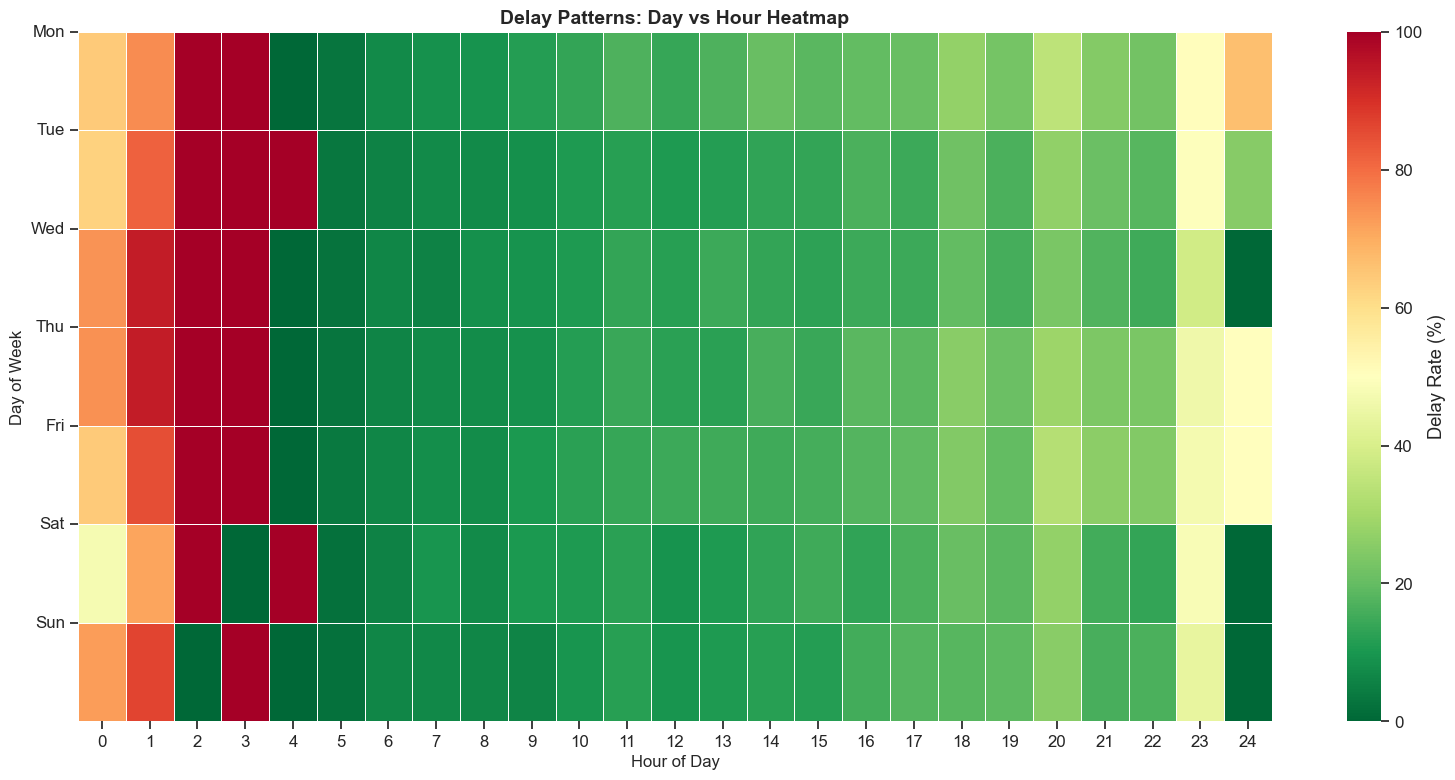

In [15]:
# Create day-hour heatmap
pivot_data = df.groupby(['DAY_OF_WEEK', 'HOUR'])['IS_DELAYED'].mean() * 100
pivot_table = pivot_data.unstack(fill_value=0)

plt.figure(figsize=(16, 8))
sns.heatmap(pivot_table, annot=False, fmt='.1f', cmap='RdYlGn_r', 
            cbar_kws={'label': 'Delay Rate (%)'}, linewidths=0.5)
plt.yticks(range(7), day_names, rotation=0)
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Day of Week', fontsize=12)
plt.title('Delay Patterns: Day vs Hour Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(
    f"{VIZ_PATH}/viz03_day_hour_heatmap.png",
    bbox_inches="tight",
    dpi=150
)
plt.show()

### 4.3 Route Analysis

In [16]:
df['ROUTE'] = df['ORIGIN'] + '-' + df['DEST']

# Calculate route statistics
route_stats = df.groupby('ROUTE').agg({
    'IS_DELAYED': ['mean', 'count'],
    'ARR_DELAY': ['mean', 'std'],
    'DISTANCE': 'first'
}).round(2)

route_stats.columns = ['delay_rate', 'flight_count', 'avg_delay_min', 'delay_std', 'distance']
route_stats['delay_rate'] *= 100

# Filter for routes with significant traffic taking minimum 50 flights
min_flights = 50
route_stats_filtered = route_stats[route_stats['flight_count'] >= min_flights].copy()

print(f"\nRoute Statistics:")
print(f"   Total unique routes: {len(route_stats):,}")
print(f"   Routes with {min_flights}+ flights: {len(route_stats_filtered):,}")
print(f"   Average flights per route: {route_stats['flight_count'].mean():.1f}")
print(f"   Most frequent route: {route_stats['flight_count'].idxmax()} ({route_stats['flight_count'].max():,} flights)")


Route Statistics:
   Total unique routes: 383
   Routes with 50+ flights: 313
   Average flights per route: 386.6
   Most frequent route: ATL-MCO (1,818 flights)


In [17]:
# Identify best and worst performing routes
worst_routes = route_stats_filtered.nlargest(15, 'delay_rate')
best_routes = route_stats_filtered.nsmallest(15, 'delay_rate')

print(f"Worst Performing Routes (highest delay rates):")
print(worst_routes[['delay_rate', 'flight_count', 'distance']].head(5))

print(f"Best Performing Routes (lowest delay rates):")
print(best_routes[['delay_rate', 'flight_count', 'distance']].head(5))

# Analyze busiest routes
busiest_routes = route_stats.nlargest(10, 'flight_count')
print(f"\nBusiest Routes (top 20 by flight volume):")
print(busiest_routes[['flight_count', 'delay_rate', 'distance']])

# Calculate statistics for busiest routes
print(f"\nBusiest Routes Analysis:")
print(f"  * Average delay rate: {busiest_routes['delay_rate'].mean():.1f}%")
print(f"  * Range: {busiest_routes['delay_rate'].min():.1f}% - {busiest_routes['delay_rate'].max():.1f}%")
print(f"  * Note: High-volume routes show {busiest_routes['delay_rate'].mean() - route_stats_filtered['delay_rate'].mean():.1f} percentage points {'higher' if busiest_routes['delay_rate'].mean() > route_stats_filtered['delay_rate'].mean() else 'lower'} delay rate than average")

Worst Performing Routes (highest delay rates):
         delay_rate  flight_count  distance
ROUTE                                      
ATL-EWR     30.0000          1181       746
ATL-GRK     29.0000            79       803
SAV-BOS     29.0000            96       901
SAV-LGA     28.0000           120       722
ATL-COS     26.0000            72      1184
Best Performing Routes (lowest delay rates):
         delay_rate  flight_count  distance
ROUTE                                      
HNL-ATL      2.0000            61      4502
ABQ-ATL      4.0000           170      1269
FNT-ATL      4.0000           197       645
TUS-ATL      6.0000           147      1541
ECP-ATL      7.0000           350       240

Busiest Routes (top 20 by flight volume):
         flight_count  delay_rate  distance
ROUTE                                      
ATL-MCO          1818     15.0000       404
MCO-ATL          1751     13.0000       404
ATL-LGA          1736     18.0000       762
LGA-ATL          1686     16.

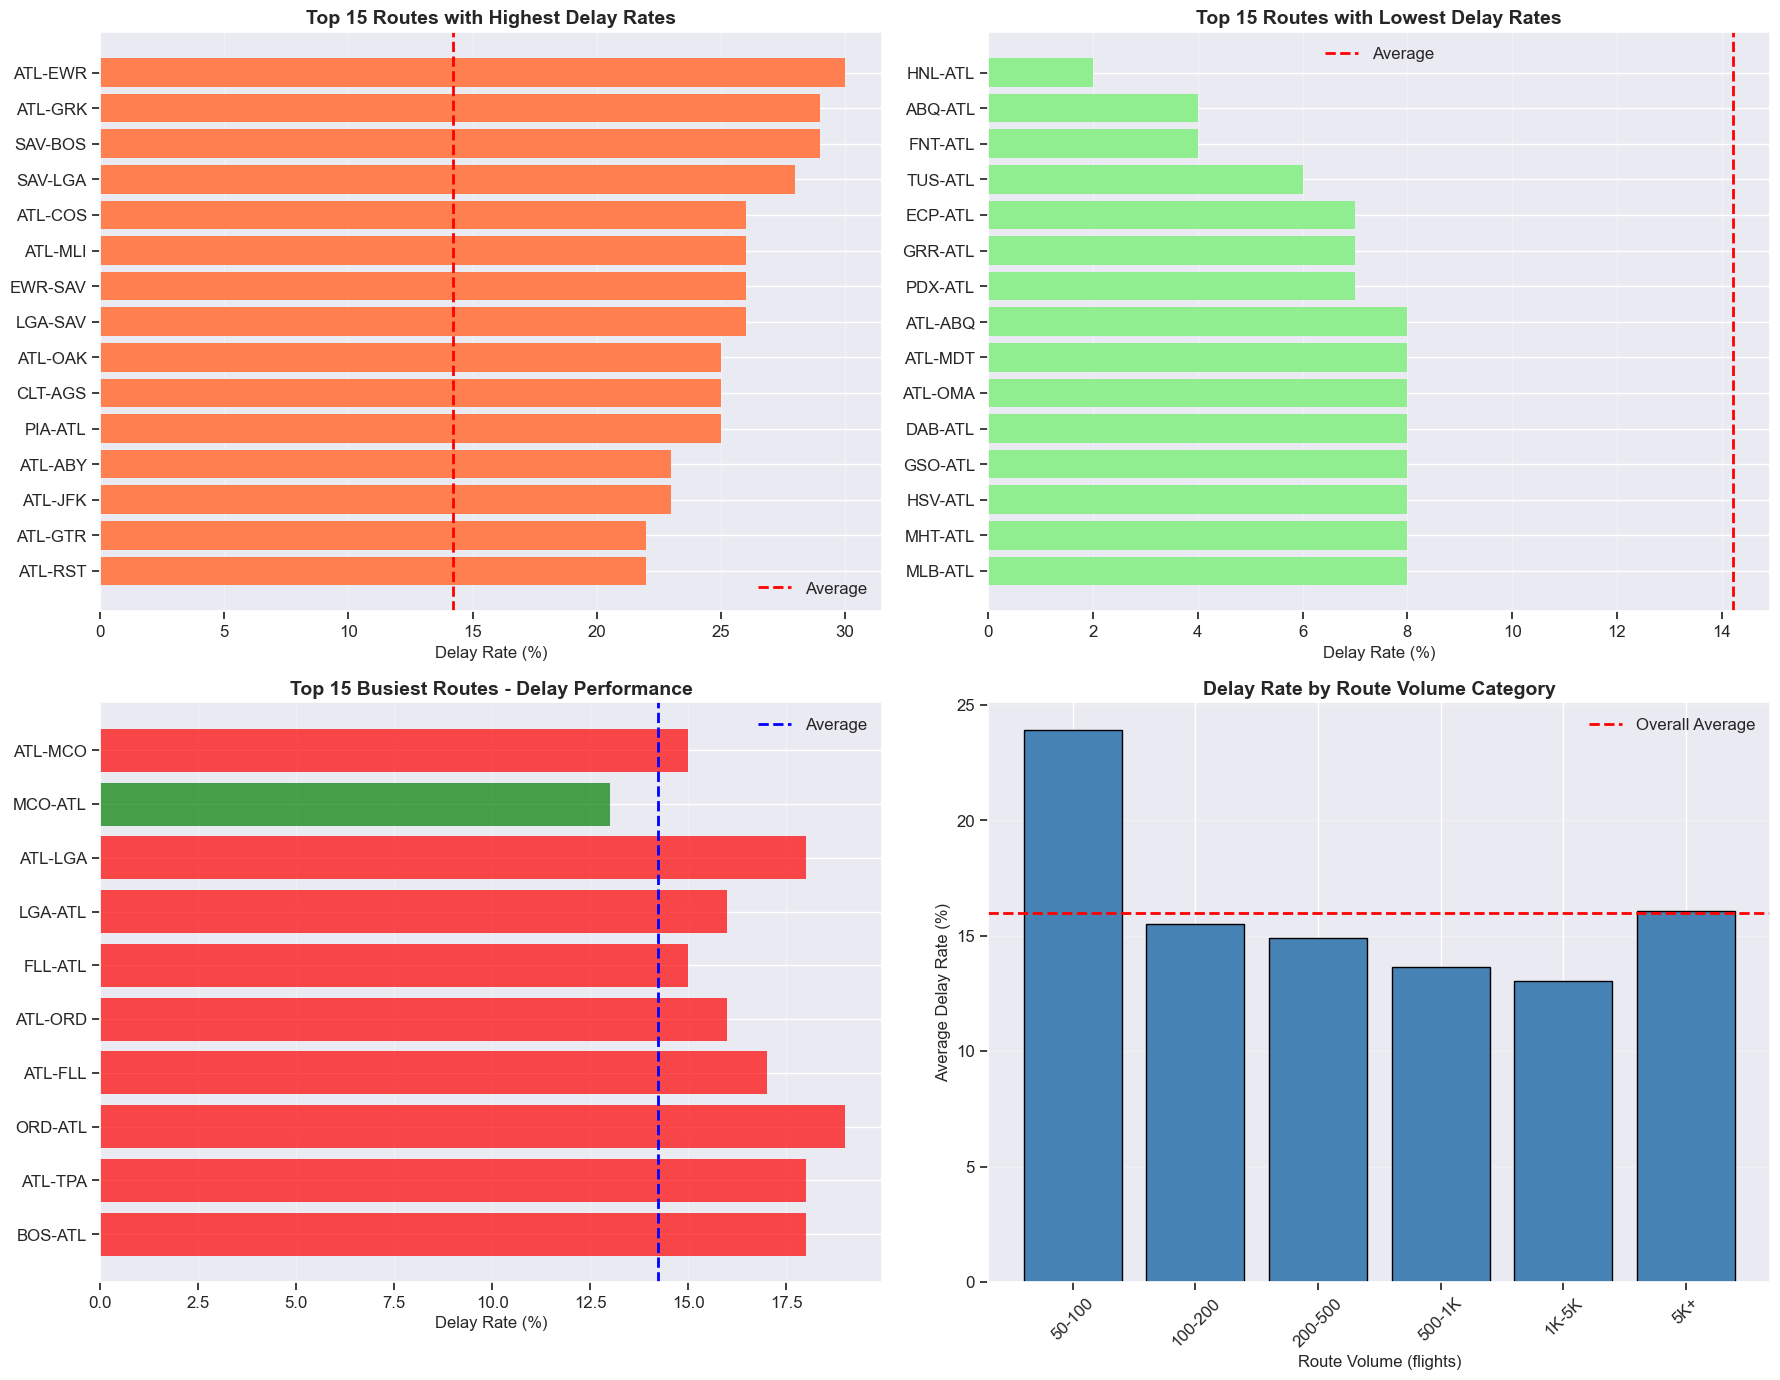

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Top 10 worst routes
top_worst = worst_routes.head(15)
axes[0, 0].barh(range(len(top_worst)), top_worst['delay_rate'].values, color='coral')
axes[0, 0].set_yticks(range(len(top_worst)))
axes[0, 0].set_yticklabels(top_worst.index)
axes[0, 0].set_xlabel('Delay Rate (%)', fontsize=12)
axes[0, 0].set_title('Top 15 Routes with Highest Delay Rates', fontsize=14, fontweight='bold')
axes[0, 0].axvline(x=route_stats_filtered['delay_rate'].mean(), color='red', 
                   linestyle='--', linewidth=2, label='Average')
axes[0, 0].legend()
axes[0, 0].grid(axis='x', alpha=0.3)
axes[0, 0].invert_yaxis()

# Top 10 best routes
top_best = best_routes.head(15)
axes[0, 1].barh(range(len(top_best)), top_best['delay_rate'].values, color='lightgreen')
axes[0, 1].set_yticks(range(len(top_best)))
axes[0, 1].set_yticklabels(top_best.index)
axes[0, 1].set_xlabel('Delay Rate (%)', fontsize=12)
axes[0, 1].set_title('Top 15 Routes with Lowest Delay Rates', fontsize=14, fontweight='bold')
axes[0, 1].axvline(x=route_stats_filtered['delay_rate'].mean(), color='red', 
                   linestyle='--', linewidth=2, label='Average')
axes[0, 1].legend()
axes[0, 1].grid(axis='x', alpha=0.3)
axes[0, 1].invert_yaxis()

# Busiest routes performance
top_busiest = busiest_routes.head(15)
colors_busy = ['red' if x > route_stats_filtered['delay_rate'].mean() else 'green' 
               for x in top_busiest['delay_rate']]
axes[1, 0].barh(range(len(top_busiest)), top_busiest['delay_rate'].values, color=colors_busy, alpha=0.7)
axes[1, 0].set_yticks(range(len(top_busiest)))
axes[1, 0].set_yticklabels(top_busiest.index)
axes[1, 0].set_xlabel('Delay Rate (%)', fontsize=12)
axes[1, 0].set_title('Top 15 Busiest Routes - Delay Performance', fontsize=14, fontweight='bold')
axes[1, 0].axvline(x=route_stats_filtered['delay_rate'].mean(), color='blue', 
                   linestyle='--', linewidth=2, label='Average')
axes[1, 0].legend()
axes[1, 0].grid(axis='x', alpha=0.3)
axes[1, 0].invert_yaxis()

# Route volume distribution
route_volume_bins = [0, 50, 100, 200, 500, 1000, 5000]
route_volume_labels = ['50-100', '100-200', '200-500', '500-1K', '1K-5K', '5K+']
route_stats['volume_category'] = pd.cut(route_stats['flight_count'], 
                                         bins=route_volume_bins, 
                                         labels=route_volume_labels)

volume_delay = route_stats.groupby('volume_category', observed=True)['delay_rate'].mean()
axes[1, 1].bar(range(len(volume_delay)), volume_delay.values, color='steelblue', edgecolor='black')
axes[1, 1].set_xticks(range(len(volume_delay)))
axes[1, 1].set_xticklabels(volume_delay.index, rotation=45)
axes[1, 1].set_ylabel('Average Delay Rate (%)', fontsize=12)
axes[1, 1].set_xlabel('Route Volume (flights)', fontsize=12)
axes[1, 1].set_title('Delay Rate by Route Volume Category', fontsize=14, fontweight='bold')
axes[1, 1].axhline(y=route_stats['delay_rate'].mean(), color='red', 
                   linestyle='--', linewidth=2, label='Overall Average')
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(
    f"{VIZ_PATH}/viz05_route_analysis.png",
    bbox_inches="tight",
    dpi=150
)
plt.show()

In [19]:
# Checking if return routes have different delay patterns

# Find routes with reverse pairs
routes_with_reverse = []
for route in route_stats_filtered.index:
    origin, dest = route.split('-')
    reverse_route = f"{dest}-{origin}"
    if reverse_route in route_stats_filtered.index:
        if route < reverse_route:  # Avoid duplicates
            routes_with_reverse.append((route, reverse_route))

print(f"\nBidirectional Route Pairs: {len(routes_with_reverse)}")

# Analyze differences in directional performance
if len(routes_with_reverse) > 0:
    directional_diffs = []
    for route1, route2 in routes_with_reverse[:20]:  # Analyze top 20 pairs
        rate1 = route_stats_filtered.loc[route1, 'delay_rate']
        rate2 = route_stats_filtered.loc[route2, 'delay_rate']
        diff = abs(rate1 - rate2)
        directional_diffs.append({
            'route_pair': f"{route1} vs {route2}",
            'rate_1': rate1,
            'rate_2': rate2,
            'difference': diff
        })
    
    directional_df = pd.DataFrame(directional_diffs).sort_values('difference', ascending=False)
    
    print(f"\nTop 10 Route Pairs with Largest Directional Differences:")
    print(directional_df.head(10))
    
    avg_directional_diff = directional_df['difference'].mean()
    print(f"\nAverage directional difference: {avg_directional_diff:.1f} percentage points")
    print(f"Interpretation: {'Significant' if avg_directional_diff > 3 else 'Moderate' if avg_directional_diff > 1 else 'Minimal'} directional effect")



Bidirectional Route Pairs: 156

Top 10 Route Pairs with Largest Directional Differences:
            route_pair  rate_1  rate_2  difference
2   ABY-ATL vs ATL-ABY 15.0000 23.0000      8.0000
15  ATL-BQK vs BQK-ATL 14.0000 21.0000      7.0000
5   AGS-CLT vs CLT-AGS 19.0000 25.0000      6.0000
7   ATL-ATW vs ATW-ATL 16.0000 10.0000      6.0000
13  ATL-BNA vs BNA-ATL 17.0000 12.0000      5.0000
8   ATL-AUS vs AUS-ATL 15.0000 11.0000      4.0000
1   ABQ-ATL vs ATL-ABQ  4.0000  8.0000      4.0000
17  ATL-BTV vs BTV-ATL 11.0000 14.0000      3.0000
16  ATL-BTR vs BTR-ATL 19.0000 16.0000      3.0000
19  ATL-BWI vs BWI-ATL 14.0000 17.0000      3.0000

Average directional difference: 3.1 percentage points
Interpretation: Significant directional effect


In [20]:
# Add carrier-route combinations
df['CARRIER_ROUTE'] = df['UNIQUE_CARRIER'] + '-' + df['ROUTE']

carrier_route_stats = df.groupby('CARRIER_ROUTE').agg({
    'IS_DELAYED': ['mean', 'count']
}).round(3)
carrier_route_stats.columns = ['delay_rate', 'flight_count']
carrier_route_stats['delay_rate'] *= 100

# Filter for carrier-routes with significant traffic
carrier_route_filtered = carrier_route_stats[carrier_route_stats['flight_count'] >= 30]

print(f"\nCarrier-Route Combinations:")
print(f"   Total unique carrier-routes: {len(carrier_route_stats):,}")
print(f"   Carrier-routes with 30+ flights: {len(carrier_route_filtered):,}")

# Find routes served by multiple carriers
route_carrier_count = df.groupby('ROUTE')['UNIQUE_CARRIER'].nunique()
competitive_routes = route_carrier_count[route_carrier_count > 1].sort_values(ascending=False)

print(f"\nRoute Competition Analysis:")
print(f"   Routes served by multiple carriers: {len(competitive_routes):,}")
print(f"   Most competitive route: {competitive_routes.index[0]} ({competitive_routes.iloc[0]} carriers)")

# Analyze performance on competitive routes
print(f"\nTop 10 Most Competitive Routes:")
for route in competitive_routes.head(10).index:
    carriers_on_route = df[df['ROUTE'] == route].groupby('UNIQUE_CARRIER')['IS_DELAYED'].agg(['mean', 'count'])
    carriers_on_route['mean'] *= 100
    carriers_on_route = carriers_on_route[carriers_on_route['count'] >= 20]  # Minimum 20 flights
    
    if len(carriers_on_route) > 1:
        print(f"\n   {route} ({competitive_routes[route]} carriers):")
        for carrier in carriers_on_route.index:
            print(f"      {carrier}: {carriers_on_route.loc[carrier, 'mean']:.1f}% delay rate ({int(carriers_on_route.loc[carrier, 'count'])} flights)")



Carrier-Route Combinations:
   Total unique carrier-routes: 912
   Carrier-routes with 30+ flights: 642

Route Competition Analysis:
   Routes served by multiple carriers: 267
   Most competitive route: ATL-IAH (9 carriers)

Top 10 Most Competitive Routes:



   ATL-IAH (9 carriers):
      9E: 31.0% delay rate (29 flights)
      DL: 14.8% delay rate (438 flights)
      NK: 11.0% delay rate (73 flights)
      OO: 42.4% delay rate (33 flights)
      UA: 15.9% delay rate (88 flights)
      YV: 10.1% delay rate (109 flights)

   IAH-ATL (9 carriers):
      DL: 14.6% delay rate (453 flights)
      NK: 14.8% delay rate (81 flights)
      OO: 32.0% delay rate (50 flights)
      UA: 13.8% delay rate (138 flights)
      YV: 15.3% delay rate (72 flights)

   ATL-ORD (9 carriers):
      AA: 16.7% delay rate (168 flights)
      DL: 15.5% delay rate (754 flights)
      MQ: 17.9% delay rate (39 flights)
      NK: 10.7% delay rate (75 flights)
      OO: 22.1% delay rate (258 flights)
      UA: 15.6% delay rate (167 flights)
      YX: 2.2% delay rate (46 flights)

   ORD-ATL (8 carriers):
      AA: 27.9% delay rate (147 flights)
      DL: 17.5% delay rate (692 flights)
      MQ: 8.3% delay rate (36 flights)
      NK: 25.7% delay rate (70 flights)
      OO


   DEN-ATL (6 carriers):
      DL: 12.0% delay rate (552 flights)
      F9: 17.2% delay rate (116 flights)
      OO: 5.8% delay rate (52 flights)
      UA: 5.8% delay rate (121 flights)
      WN: 17.9% delay rate (263 flights)

   ATL-DEN (6 carriers):
      DL: 13.9% delay rate (552 flights)
      F9: 22.1% delay rate (113 flights)
      OO: 23.0% delay rate (61 flights)
      UA: 10.4% delay rate (106 flights)
      WN: 18.8% delay rate (255 flights)
      YX: 0.0% delay rate (21 flights)

   LGA-ATL (5 carriers):
      AA: 25.8% delay rate (120 flights)
      DL: 14.2% delay rate (1053 flights)
      F9: 16.0% delay rate (75 flights)
      WN: 17.8% delay rate (366 flights)
      YX: 19.4% delay rate (72 flights)

   ATL-LGA (5 carriers):
      AA: 20.6% delay rate (131 flights)
      DL: 17.9% delay rate (1110 flights)
      F9: 7.8% delay rate (77 flights)
      WN: 20.9% delay rate (350 flights)
      YX: 17.6% delay rate (68 flights)

   ATL-MCO (5 carriers):
      DL: 12.5% de


   ATL-DCA (5 carriers):
      DL: 14.6% delay rate (815 flights)
      WN: 17.5% delay rate (315 flights)
      YX: 8.5% delay rate (82 flights)


In [21]:
print(f"\n1. Route Variability:")
print(f"   Delay rate range: {route_stats_filtered['delay_rate'].min():.1f}% - {route_stats_filtered['delay_rate'].max():.1f}%")
print(f"   Spread: {route_stats_filtered['delay_rate'].max() - route_stats_filtered['delay_rate'].min():.1f} percentage points")
print(f"   Standard deviation: {route_stats_filtered['delay_rate'].std():.1f} percentage points")

print(f"\n2. Volume vs Performance:")
print(f"   Busiest routes average: {busiest_routes['delay_rate'].mean():.1f}% delays")
print(f"   Overall average: {route_stats_filtered['delay_rate'].mean():.1f}% delays")
print(f"   High-volume routes perform {'worse' if busiest_routes['delay_rate'].mean() > route_stats_filtered['delay_rate'].mean() else 'better'} than average")


1. Route Variability:
   Delay rate range: 2.0% - 30.0%
   Spread: 28.0 percentage points
   Standard deviation: 4.5 percentage points

2. Volume vs Performance:
   Busiest routes average: 16.5% delays
   Overall average: 14.2% delays
   High-volume routes perform worse than average


### 4.4 Geograhical Analysis

In [22]:
# Airport (Origin) statistics
origin_stats = df.groupby('ORIGIN').agg({
    'IS_DELAYED': ['mean', 'count'],
    'ARR_DELAY': ['mean', 'std'],
    'DISTANCE': 'mean'
}).round(2)

origin_stats.columns = ['delay_rate', 'flight_count', 'avg_delay_min', 'delay_std', 'avg_distance']
origin_stats['delay_rate'] *= 100

# Airport (Destination) statistics
dest_stats = df.groupby('DEST').agg({
    'IS_DELAYED': ['mean', 'count'],
    'ARR_DELAY': ['mean', 'std'],
    'DISTANCE': 'mean'
}).round(2)

dest_stats.columns = ['delay_rate', 'flight_count', 'avg_delay_min', 'delay_std', 'avg_distance']
dest_stats['delay_rate'] *= 100

# State (Origin) statistics
state_stats = df.groupby('ORIGIN_STATE_ABR').agg({
    'IS_DELAYED': ['mean', 'count'],
    'ARR_DELAY': ['mean', 'std']
}).round(2)

state_stats.columns = ['delay_rate', 'flight_count', 'avg_delay_min', 'delay_std']
state_stats['delay_rate'] *= 100

# Filter for significant traffic
min_flights = 200
origin_stats_filtered = origin_stats[origin_stats['flight_count'] >= min_flights].copy()
dest_stats_filtered   = dest_stats[dest_stats['flight_count'] >= min_flights].copy()
state_stats_filtered  = state_stats[state_stats['flight_count'] >= min_flights].copy()

print("\nGeographic Statistics:")
print(f"   Total unique origin airports: {len(origin_stats):,}")
print(f"   Origin airports with {min_flights}+ flights: {len(origin_stats_filtered):,}")
print(f"   Total unique destination airports: {len(dest_stats):,}")
print(f"   Destination airports with {min_flights}+ flights: {len(dest_stats_filtered):,}")
print(f"   Total unique origin states: {len(state_stats):,}")
print(f"   Origin states with {min_flights}+ flights: {len(state_stats_filtered):,}")

print(f"\nMost frequent origin airport: {origin_stats['flight_count'].idxmax()} ({origin_stats['flight_count'].max():,} flights)")
print(f"Most frequent destination airport: {dest_stats['flight_count'].idxmax()} ({dest_stats['flight_count'].max():,} flights)")

# Identify worst performing airports/states (by delay rate)
worst_origin = origin_stats_filtered.nlargest(10, 'delay_rate')
worst_dest   = dest_stats_filtered.nlargest(10, 'delay_rate')
worst_states = state_stats_filtered.nlargest(10, 'delay_rate')

print("\nWorst Origin Airports (highest delay rates):")
print(worst_origin[['delay_rate', 'flight_count', 'avg_distance']].head(5))

print("\nWorst Destination Airports (highest delay rates):")
print(worst_dest[['delay_rate', 'flight_count', 'avg_distance']].head(5))

print("\nWorst Origin States (highest delay rates):")
print(worst_states[['delay_rate', 'flight_count']].head(5))

# Analyze busiest airports by flight volume (origin)
busiest_origin = origin_stats.nlargest(10, 'flight_count')
print("\nBusiest Origin Airports (top 10 by flight volume):")
print(busiest_origin[['flight_count', 'delay_rate', 'avg_distance']])

print("\nBusiest Origin Airports Analysis:")
print(f"  * Average delay rate: {busiest_origin['delay_rate'].mean():.1f}%")
print(f"  * Range: {busiest_origin['delay_rate'].min():.1f}% - {busiest_origin['delay_rate'].max():.1f}%")
print(f"  * Note: High-volume origin airports show "
      f"{busiest_origin['delay_rate'].mean() - origin_stats_filtered['delay_rate'].mean():.1f} percentage points "
      f"{'higher' if busiest_origin['delay_rate'].mean() > origin_stats_filtered['delay_rate'].mean() else 'lower'} "
      f"delay rate than average")


Geographic Statistics:
   Total unique origin airports: 167
   Origin airports with 200+ flights: 113
   Total unique destination airports: 166
   Destination airports with 200+ flights: 108
   Total unique origin states: 50
   Origin states with 200+ flights: 38

Most frequent origin airport: ATL (72,561 flights)
Most frequent destination airport: ATL (72,730 flights)

Worst Origin Airports (highest delay rates):
        delay_rate  flight_count  avg_distance
ORIGIN                                        
MGM        22.0000           346      147.0000
MOB        21.0000           364      302.0000
FAY        20.0000           276      331.0000
FWA        20.0000           284      508.0000
HPN        20.0000           387      780.0700

Worst Destination Airports (highest delay rates):
      delay_rate  flight_count  avg_distance
DEST                                        
EWR      28.0000          1370      740.7600
MLI      26.0000           201      633.0000
JFK      23.0000     


Busiest Origin Airports (top 10 by flight volume):
        flight_count  delay_rate  avg_distance
ORIGIN                                        
ATL            72561     15.0000      659.1500
SAV             1981     15.0000      506.0600
LGA             1799     17.0000      759.3900
MCO             1751     13.0000      404.0000
FLL             1577     15.0000      581.0000
ORD             1571     19.0000      618.1600
BOS             1484     18.0000      943.0300
CLT             1460     14.0000      218.0400
DFW             1457     15.0000      742.6500
TPA             1360     17.0000      406.0000

Busiest Origin Airports Analysis:
  * Average delay rate: 15.8%
  * Range: 13.0% - 19.0%
  * Note: High-volume origin airports show 2.9 percentage points higher delay rate than average


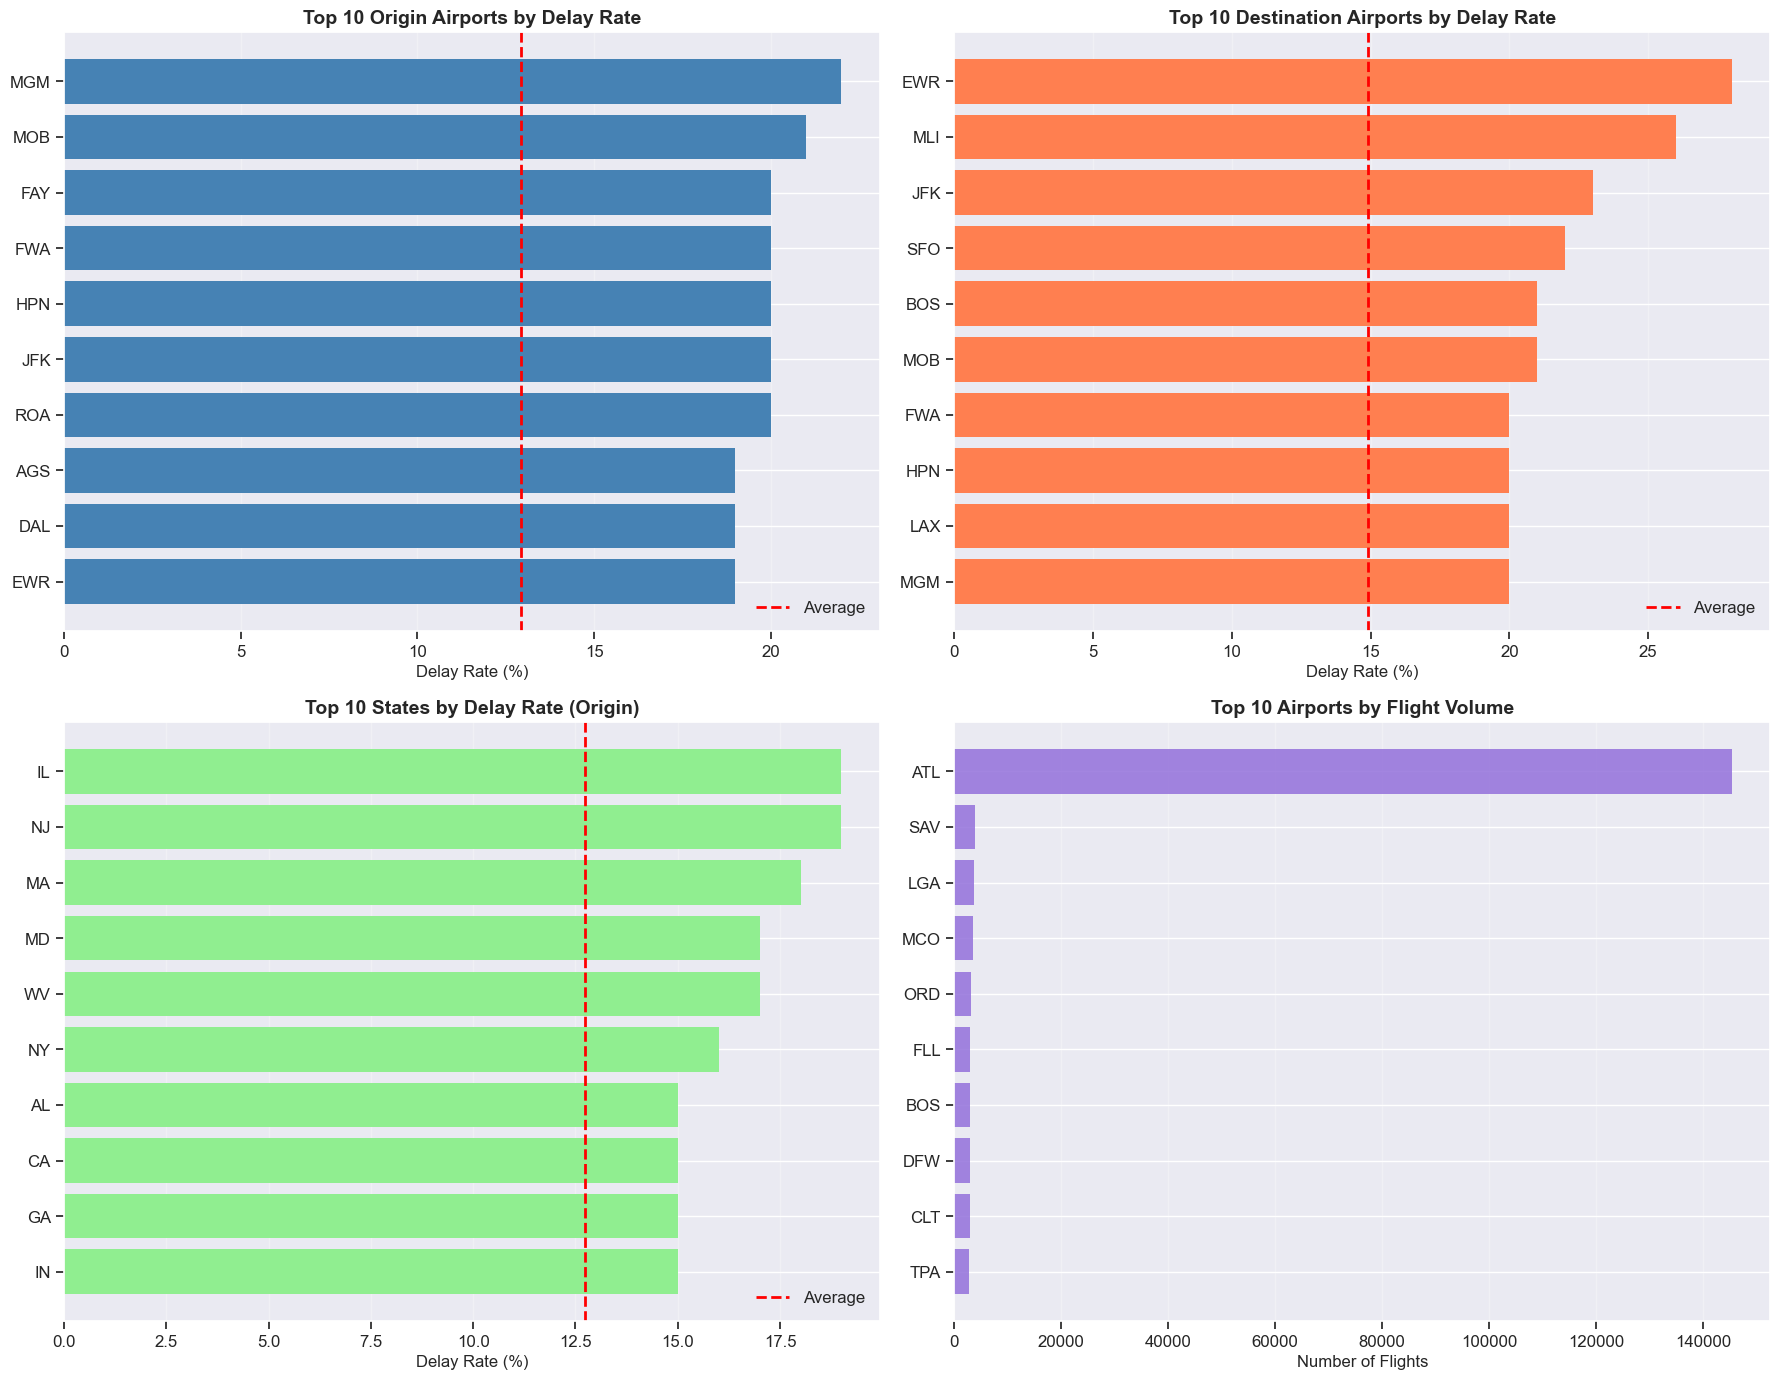

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Top 10 worst ORIGIN airports by delay rate
top_worst_origin = worst_origin.head(10)
axes[0, 0].barh(range(len(top_worst_origin)), top_worst_origin['delay_rate'].values, color='steelblue')
axes[0, 0].set_yticks(range(len(top_worst_origin)))
axes[0, 0].set_yticklabels(top_worst_origin.index)
axes[0, 0].set_xlabel('Delay Rate (%)', fontsize=12)
axes[0, 0].set_title('Top 10 Origin Airports by Delay Rate', fontsize=14, fontweight='bold')
axes[0, 0].axvline(x=origin_stats_filtered['delay_rate'].mean(), color='red',
                   linestyle='--', linewidth=2, label='Average')
axes[0, 0].legend()
axes[0, 0].grid(axis='x', alpha=0.3)
axes[0, 0].invert_yaxis()

# Top 10 worst DEST airports by delay rate
top_worst_dest = worst_dest.head(10)
axes[0, 1].barh(range(len(top_worst_dest)), top_worst_dest['delay_rate'].values, color='coral')
axes[0, 1].set_yticks(range(len(top_worst_dest)))
axes[0, 1].set_yticklabels(top_worst_dest.index)
axes[0, 1].set_xlabel('Delay Rate (%)', fontsize=12)
axes[0, 1].set_title('Top 10 Destination Airports by Delay Rate', fontsize=14, fontweight='bold')
axes[0, 1].axvline(x=dest_stats_filtered['delay_rate'].mean(), color='red',
                   linestyle='--', linewidth=2, label='Average')
axes[0, 1].legend()
axes[0, 1].grid(axis='x', alpha=0.3)
axes[0, 1].invert_yaxis()

# Top 10 worst ORIGIN states by delay rate
top_worst_states = worst_states.head(10)
axes[1, 0].barh(range(len(top_worst_states)), top_worst_states['delay_rate'].values, color='lightgreen')
axes[1, 0].set_yticks(range(len(top_worst_states)))
axes[1, 0].set_yticklabels(top_worst_states.index)
axes[1, 0].set_xlabel('Delay Rate (%)', fontsize=12)
axes[1, 0].set_title('Top 10 States by Delay Rate (Origin)', fontsize=14, fontweight='bold')
axes[1, 0].axvline(x=state_stats_filtered['delay_rate'].mean(), color='red',
                   linestyle='--', linewidth=2, label='Average')
axes[1, 0].legend()
axes[1, 0].grid(axis='x', alpha=0.3)
axes[1, 0].invert_yaxis()

top_n = 10

# Calculate total airport volume (count appearances in ORIGIN and DEST)
airport_total_counts = pd.concat([df["ORIGIN"], df["DEST"]]).value_counts()

# Keep top N as a DataFrame with the same structure you want
top_volume = airport_total_counts.head(top_n).to_frame("flight_count")

# Plot (your exact format)
axes[1, 1].barh(
    range(len(top_volume)),
    top_volume["flight_count"].values,
    color="mediumpurple",
    alpha=0.85
)
axes[1, 1].set_yticks(range(len(top_volume)))
axes[1, 1].set_yticklabels(top_volume.index)
axes[1, 1].set_xlabel("Number of Flights", fontsize=12)
axes[1, 1].set_title(f"Top {top_n} Airports by Flight Volume", fontsize=14, fontweight="bold")
axes[1, 1].grid(axis="x", alpha=0.3)
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.savefig(
    f"{VIZ_PATH}/viz04_geographic_analysis.png",
    bbox_inches="tight",
    dpi=150
)
plt.show()


### 4.5 Carrier Performance Analysis

In [24]:
# Carrier analysis
carrier_stats = df.groupby('UNIQUE_CARRIER').agg({
    'IS_DELAYED': ['mean', 'count']
})
carrier_stats.columns = ['delay_rate', 'flight_count']
carrier_stats['delay_rate'] *= 100
carrier_stats = carrier_stats[carrier_stats['flight_count'] >= 100]
carrier_stats = carrier_stats.sort_values('delay_rate', ascending=False)

print("Carrier Performance:")
print(f" - Total carriers: {df['UNIQUE_CARRIER'].nunique()}")
print(f" - Carriers with 100+ flights: {len(carrier_stats)}")

Carrier Performance:
 - Total carriers: 16
 - Carriers with 100+ flights: 15


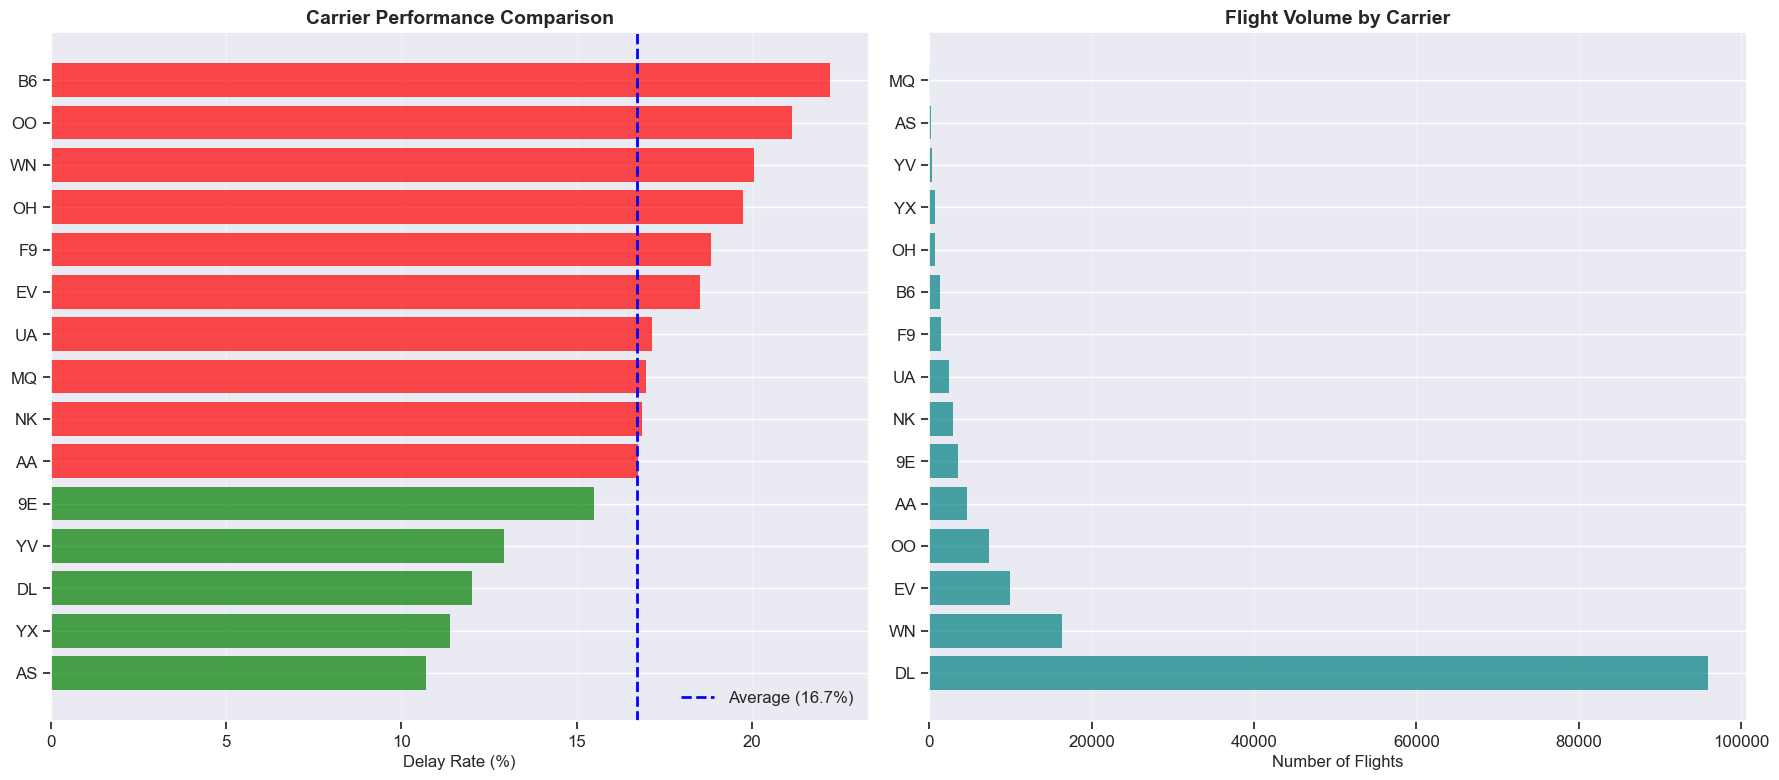

In [25]:
# Carrier visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Left: Delay rate by carrier
avg_delay = carrier_stats['delay_rate'].mean()
colors = ['red' if x > avg_delay else 'green' for x in carrier_stats['delay_rate']]
axes[0].barh(range(len(carrier_stats)), carrier_stats['delay_rate'].values, color=colors, alpha=0.7)
axes[0].axvline(x=avg_delay, color='blue', linestyle='--', linewidth=2, label=f'Average ({avg_delay:.1f}%)')
axes[0].set_yticks(range(len(carrier_stats)))
axes[0].set_yticklabels(carrier_stats.index)
axes[0].set_xlabel('Delay Rate (%)', fontsize=12)
axes[0].set_title('Carrier Performance Comparison', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(axis='x', alpha=0.3)
axes[0].invert_yaxis()

# Right: Flight volume by carrier
carrier_sorted = carrier_stats.sort_values('flight_count')
axes[1].barh(range(len(carrier_sorted)), carrier_sorted['flight_count'].values, 
            color='teal', alpha=0.7)
axes[1].set_yticks(range(len(carrier_sorted)))
axes[1].set_yticklabels(carrier_sorted.index)
axes[1].set_xlabel('Number of Flights', fontsize=12)
axes[1].set_title('Flight Volume by Carrier', fontsize=14, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(
    f"{VIZ_PATH}/viz06_carrier_analysis.png",
    bbox_inches="tight",
    dpi=150
)
plt.show()

In [26]:
# Carrier insights
print("\n Key Carrier Findings:")
print(f"\n1. Best Performers:")
for i, (carrier, row) in enumerate(carrier_stats.nsmallest(3, 'delay_rate').iterrows(), 1):
    print(f"   {i}. {carrier}: {row['delay_rate']:.1f}% delays ({int(row['flight_count']):,} flights)")

print(f"\n2. Worst Performers:")
for i, (carrier, row) in enumerate(carrier_stats.nlargest(3, 'delay_rate').iterrows(), 1):
    print(f"   {i}. {carrier}: {row['delay_rate']:.1f}% delays ({int(row['flight_count']):,} flights)")

print(f"\n3. Largest Carriers:")
for i, (carrier, row) in enumerate(carrier_stats.nlargest(3, 'flight_count').iterrows(), 1):
    print(f"   {i}. {carrier}: {int(row['flight_count']):,} flights ({row['delay_rate']:.1f}% delays)")


 Key Carrier Findings:

1. Best Performers:
   1. AS: 10.7% delays (262 flights)
   2. YX: 11.4% delays (676 flights)
   3. DL: 12.0% delays (95,931 flights)

2. Worst Performers:
   1. B6: 22.2% delays (1,283 flights)
   2. OO: 21.1% delays (7,387 flights)
   3. WN: 20.1% delays (16,370 flights)

3. Largest Carriers:
   1. DL: 95,931 flights (12.0% delays)
   2. WN: 16,370 flights (20.1% delays)
   3. EV: 9,922 flights (18.5% delays)


### 4.6 Distance Analysis

In [27]:
# Distance group analysis
distance_delays = df.groupby('DISTANCE_GROUP').agg({
    'IS_DELAYED': 'mean',
    'DISTANCE': 'count'
})
distance_delays.columns = ['delay_rate', 'count']
distance_delays['delay_rate'] *= 100

print("Distance Analysis:")
print(f" * Distance groups: {len(distance_delays)}")
print(f" * Range: {df['DISTANCE'].min():.0f} - {df['DISTANCE'].max():.0f} miles")

Distance Analysis:
 * Distance groups: 10
 * Range: 83 - 4502 miles


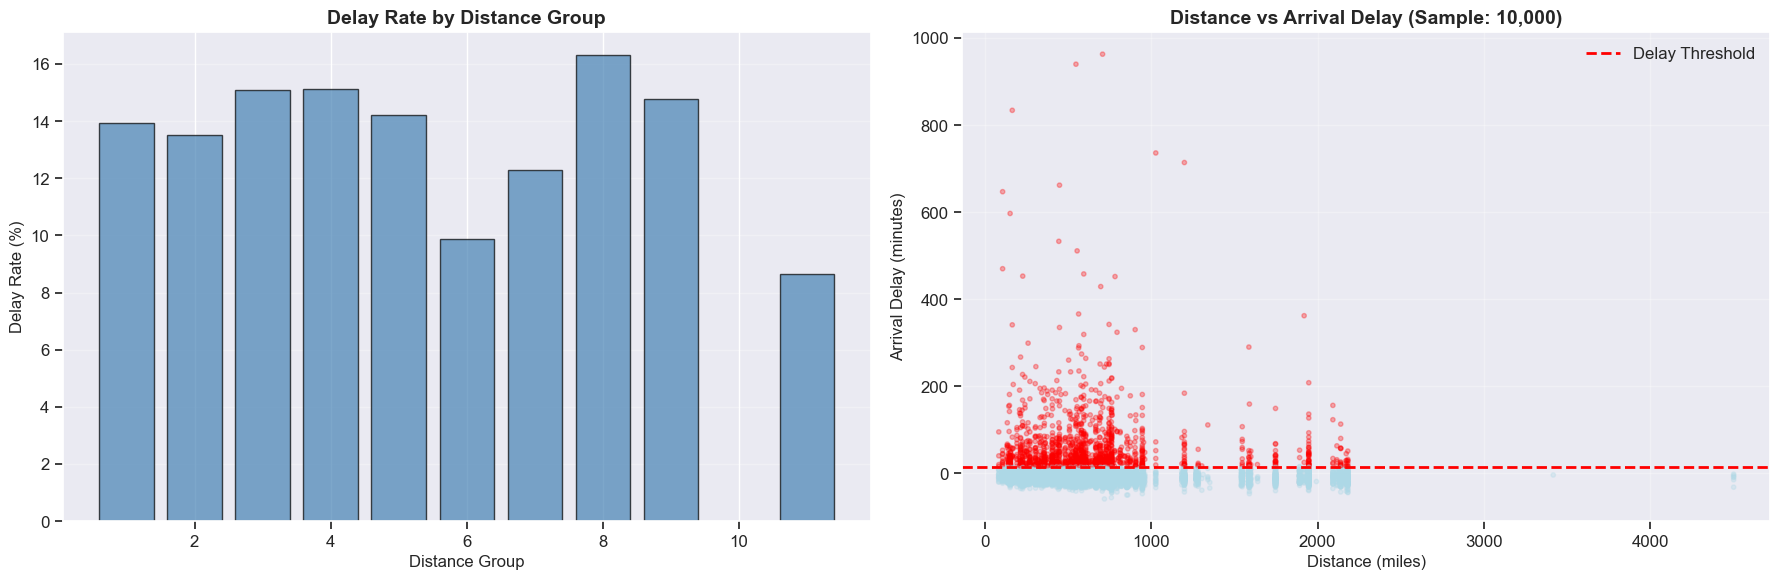

In [28]:
# Distance visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Left: Delay rate by distance group
axes[0].bar(distance_delays.index, distance_delays['delay_rate'].values, 
           color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Distance Group', fontsize=12)
axes[0].set_ylabel('Delay Rate (%)', fontsize=12)
axes[0].set_title('Delay Rate by Distance Group', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Right: Scatter plot
size = min(10000, len(df))
df_sample = df.sample(n=size, random_state=42)
colors = ['red' if d == 1 else 'lightblue' for d in df_sample['IS_DELAYED']]
axes[1].scatter(df_sample['DISTANCE'], df_sample['ARR_DELAY'], 
               c=colors, alpha=0.3, s=10)
axes[1].axhline(y=15, color='red', linestyle='--', linewidth=2, label='Delay Threshold')
axes[1].set_xlabel('Distance (miles)', fontsize=12)
axes[1].set_ylabel('Arrival Delay (minutes)', fontsize=12)
axes[1].set_title(f'Distance vs Arrival Delay (Sample: {size:,})', 
                 fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    f"{VIZ_PATH}/viz07_distance_analysis.png",
    bbox_inches="tight",
    dpi=150
)
plt.show()

### 4.7 Feature Correlation Analysis

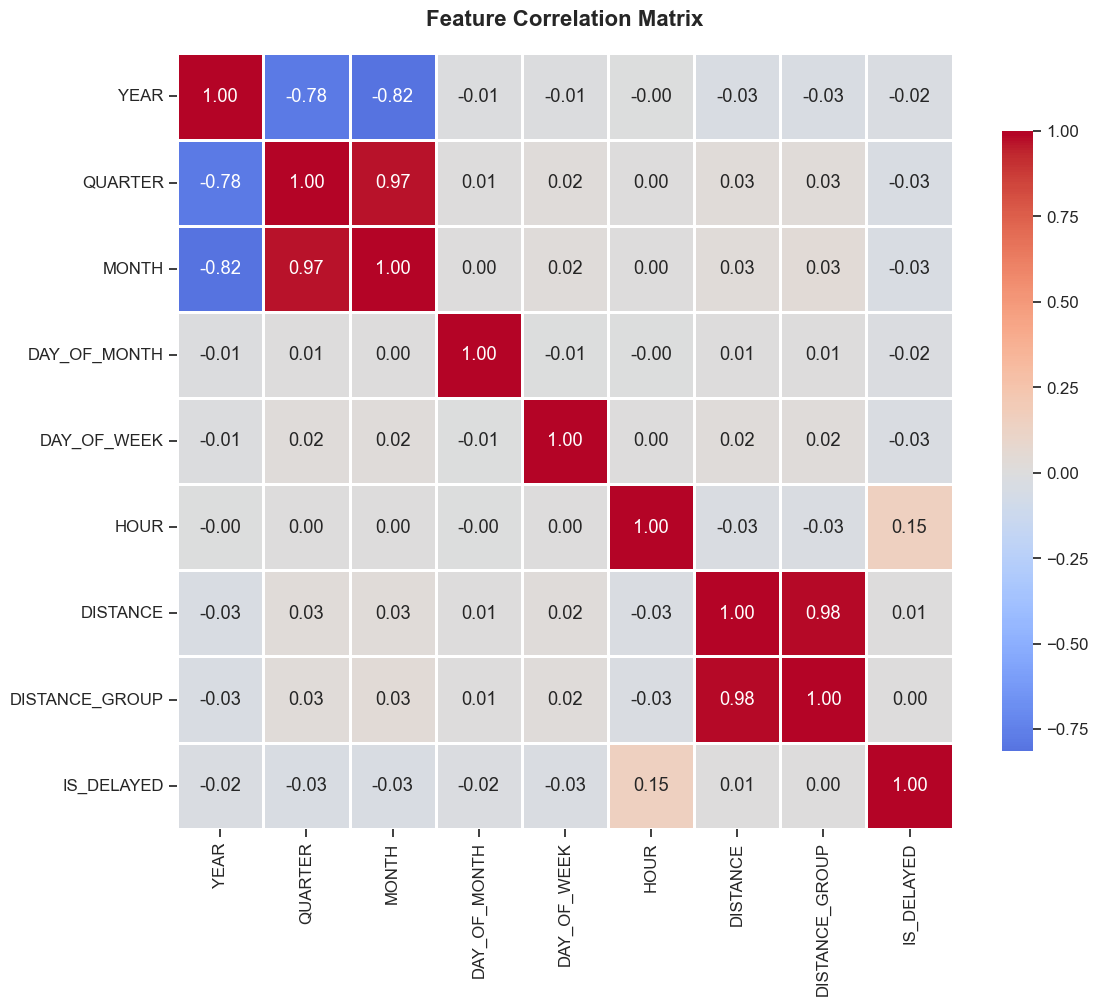

In [29]:
# Numeric features for correlation
numeric_cols = ['YEAR', 'QUARTER', 'MONTH', 'DAY_OF_MONTH', 'DAY_OF_WEEK', 
                'HOUR', 'DISTANCE', 'DISTANCE_GROUP', 'IS_DELAYED']
correlation_matrix = df[numeric_cols].corr()

# Visualize correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(
    f"{VIZ_PATH}/viz08_correlation_matrix.png",
    bbox_inches="tight",
    dpi=150
)
plt.show()

In [30]:
# Correlation with target
target_corr = correlation_matrix['IS_DELAYED'].sort_values(ascending=False)
print("\nCorrelation with IS_DELAYED:")
print(target_corr)

print(f"\n Key Correlation Insights:")
print(f"    * HOUR has strongest correlation: {target_corr['HOUR']:.3f}")
print(f"    * This is {abs(target_corr['HOUR'] / target_corr.drop('IS_DELAYED').iloc[1]):.0f}x stronger than next feature")
print(f"    * Distance has weak correlation: {target_corr['DISTANCE']:.3f}")


Correlation with IS_DELAYED:
IS_DELAYED        1.0000
HOUR              0.1508
DISTANCE          0.0055
DISTANCE_GROUP    0.0047
DAY_OF_MONTH     -0.0204
YEAR             -0.0221
DAY_OF_WEEK      -0.0253
QUARTER          -0.0282
MONTH            -0.0293
Name: IS_DELAYED, dtype: float64

 Key Correlation Insights:
    * HOUR has strongest correlation: 0.151
    * This is 27x stronger than next feature
    * Distance has weak correlation: 0.006


### 4.8 Anomaly Detection

In [31]:
# Impossible air times
bad_airtime = df[df['AIR_TIME'] <= 0]
print(f"\n1. Flights with AIR_TIME <= 0: {len(bad_airtime):,} ({len(bad_airtime)/len(df)*100:.2f}%)")

# Impossible speeds
if 'FLIGHT_SPEED_MPH' not in df.columns:
    df['FLIGHT_SPEED_MPH'] = df['DISTANCE'] / (df['AIR_TIME'] / 60)

fast_flights = df[df['FLIGHT_SPEED_MPH'] > 700]
print(f"\n2. Flights exceeding 700 mph: {len(fast_flights):,} ({len(fast_flights)/len(df)*100:.2f}%)")
    
# Extreme delays
extreme_delays = df[df['ARR_DELAY'] > 500]
print(f"\n3. Delays exceeding 500 minutes (8+ hours): {len(extreme_delays):,}")
if len(extreme_delays) > 0:
    print(f"   Max delay: {df['ARR_DELAY'].max():.0f} minutes ({df['ARR_DELAY'].max()/60:.1f} hours)")


1. Flights with AIR_TIME <= 0: 0 (0.00%)

2. Flights exceeding 700 mph: 0 (0.00%)

3. Delays exceeding 500 minutes (8+ hours): 160
   Max delay: 1455 minutes (24.2 hours)


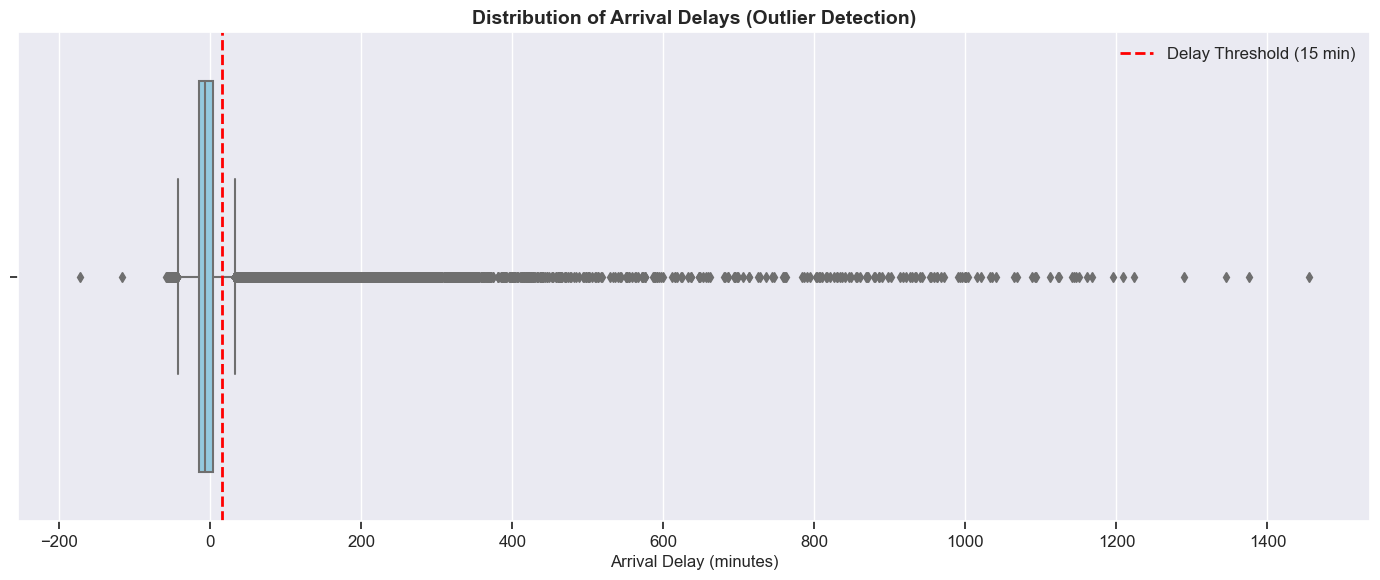

In [32]:
# Visualize extreme delays
plt.figure(figsize=(14, 6))
sns.boxplot(x=df['ARR_DELAY'], color='skyblue')
plt.axvline(x=15, color='red', linestyle='--', linewidth=2, label='Delay Threshold (15 min)')
plt.xlabel('Arrival Delay (minutes)', fontsize=12)
plt.title('Distribution of Arrival Delays (Outlier Detection)', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig(
    f"{VIZ_PATH}/viz09_anomaly_detection.png",
    bbox_inches="tight",
    dpi=150
)
plt.show()